### Python Standard Library

In [ ]:
import pandas as pd
import io
import matplotlib.pyplot as plt
import seaborn as sns

### Download Dataset

In [ ]:
!wget https://statistik.tu-dortmund.de/storages/statistik/r/Downloads/Studium/Studiengaenge-Infos/Data_Science/cycling.txt

--2025-11-25 17:36:36--  https://statistik.tu-dortmund.de/storages/statistik/r/Downloads/Studium/Studiengaenge-Infos/Data_Science/cycling.txt
Resolving statistik.tu-dortmund.de (statistik.tu-dortmund.de)... 129.217.143.204
Connecting to statistik.tu-dortmund.de (statistik.tu-dortmund.de)|129.217.143.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159939 (156K) [text/plain]
Saving to: ‘cycling.txt’

cycling.txt         100%[===================>] 156.19K   497KB/s    in 0.3s    

2025-11-25 17:36:37 (497 KB/s) - ‘cycling.txt’ saved [159939/159939]



## Load txt Dataset and convert it to csv

In [ ]:
df = pd.read_csv('cycling.txt', sep=' ', quotechar='"')

In [ ]:
print(df.head())

      all_riders  rider_class stage  points stage_class
0  Tadej Pogačar  All Rounder    X1      15        flat
1  Tadej Pogačar  All Rounder    X2     219       hills
2  Tadej Pogačar  All Rounder    X3      34        flat
3  Tadej Pogačar  All Rounder    X4     264       hills
4  Tadej Pogačar  All Rounder    X6     114       hills


## Load the csv format dataset

In [ ]:
df.to_csv('cycling_data.csv', index=False)

In [ ]:
df = pd.read_csv('cycling_data.csv')

print("DataFrame 'df' loaded successfully.")
print("Displaying the first 5 rows:")
print(df.head())

DataFrame 'df' loaded successfully.
Displaying the first 5 rows:
      all_riders  rider_class stage  points stage_class
0  Tadej Pogačar  All Rounder    X1      15        flat
1  Tadej Pogačar  All Rounder    X2     219       hills
2  Tadej Pogačar  All Rounder    X3      34        flat
3  Tadej Pogačar  All Rounder    X4     264       hills
4  Tadej Pogačar  All Rounder    X6     114       hills


In [ ]:
num_rows, num_cols = df.shape

print(f"Dataset Size:")
print(f"Number of Rows (Observations): {num_rows:,}")
print(f"Number of Columns (Features): {num_cols}")

Dataset Size:
Number of Rows (Observations): 3,496
Number of Columns (Features): 5


Check for Missing Values

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

print("\n" + "="*40)
print("Data types and non-null counts:")
df.info()

Missing values per column:
all_riders     0
rider_class    0
stage          0
points         0
stage_class    0
dtype: int64

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3496 entries, 0 to 3495
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   all_riders   3496 non-null   object
 1   rider_class  3496 non-null   object
 2   stage        3496 non-null   object
 3   points       3496 non-null   int64 
 4   stage_class  3496 non-null   object
dtypes: int64(1), object(4)
memory usage: 136.7+ KB


In [ ]:
# 1. Calculate the counts for rider_class
rider_class_counts_df = df['rider_class'].value_counts().reset_index()

# 2. Rename columns for clean output
rider_class_counts_df.columns = ['Rider Class', 'Count']

# 3. Print the results in Markdown table format
print("--- Rider Class Counts ---")
print(rider_class_counts_df.to_markdown(index=False))

# 4. Calculate and print the total number of entries
total_entries = df['rider_class'].count()
print(f"\nTotal number of entries across all Rider Class categories: {total_entries}")

--- Rider Class Counts ---
| Rider Class   |   Count |
|:--------------|--------:|
| Unclassed     |    2185 |
| Sprinter      |     551 |
| Climber       |     437 |
| All Rounder   |     323 |

Total number of entries across all Rider Class categories: 3496


In [ ]:
# Colab Code: Count Unique Stages

# Calculate the total number of unique stage identifiers (e.g., X1, X2, etc.)
unique_stage_count = df['stage'].nunique()

print(f"Total number of unique stages: {unique_stage_count}")

Total number of unique stages: 19


In [ ]:
# Simple Colab Code: Count Stage Class Entries

# Calculate the frequency count of each stage_class
stage_class_counts = df['stage_class'].value_counts().reset_index()
stage_class_counts.columns = ['Stage Class', 'Count']

# Sort the stages alphabetically for consistent output
stage_class_counts = stage_class_counts.sort_values(by='Stage Class')

print(stage_class_counts.to_markdown(index=False))

| Stage Class   |   Count |
|:--------------|--------:|
| flat          |    1104 |
| hills         |    1472 |
| mount         |     920 |


In [ ]:
# 1. Calculate the total points for each Rider Class.
total_points_by_class = df.groupby('rider_class')['points'].sum().reset_index()
total_points_by_class.columns = ['Rider Class', 'Total Points']

# 2. Sort the table to find the maximum scorer.
total_points_by_class = total_points_by_class.sort_values(by='Total Points', ascending=False)

# 3. Extract the top-scoring class.
max_scorer_class = total_points_by_class.iloc[0]

print("--- Rider Class with Maximum Total Points ---")
print(f"The Rider Class with the maximum points is: {max_scorer_class['Rider Class']}")
print(f"Total Points Scored: {max_scorer_class['Total Points']:,}\n")

print("--- Full Summary of Total Points by Class ---")
print(total_points_by_class.to_markdown(index=False))

--- Rider Class with Maximum Total Points ---
The Rider Class with the maximum points is: Unclassed
Total Points Scored: 14,027

--- Full Summary of Total Points by Class ---
| Rider Class   |   Total Points |
|:--------------|---------------:|
| Unclassed     |          14027 |
| All Rounder   |          12173 |
| Climber       |           8814 |
| Sprinter      |           8285 |


In [ ]:
# Code to recreate the Average Points Matrix:
df.pivot_table(index='rider_class', columns='stage_class', values='points', aggfunc='mean').round(2)

stage_class,flat,hills,mount
rider_class,,,
All Rounder,15.44,35.79,67.42
Climber,5.09,21.67,35.86
Sprinter,38.98,5.20,2.04
Unclassed,5.74,9.10,2.95


In [ ]:
df['rider_class'].value_counts()

,count
rider_class,
Unclassed,2185
Sprinter,551
Climber,437
All Rounder,323


In [ ]:
df.groupby('rider_class')['points'].describe()

,count,mean,std,min,25%,50%,75%,max
rider_class,,,,,,,,
All Rounder,323.0,37.687307,63.961640,0.0,0.0,12.0,39.5,304.0
Climber,437.0,20.169336,43.447254,0.0,0.0,6.0,16.0,269.0
Sprinter,551.0,15.036298,41.832247,0.0,0.0,0.0,4.0,272.0
Unclassed,2185.0,6.419680,23.282527,0.0,0.0,0.0,2.0,260.0


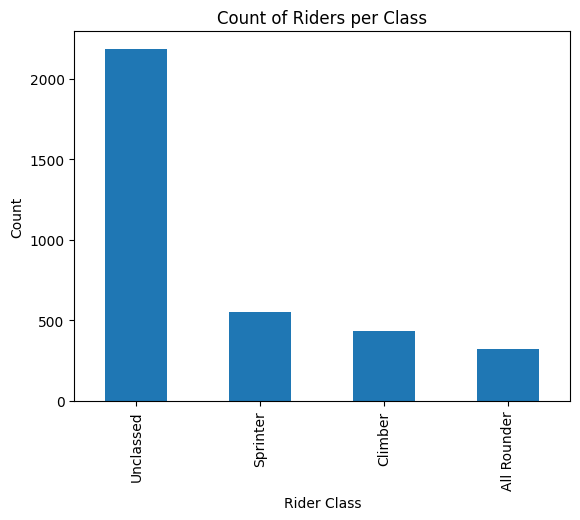

In [ ]:
df['rider_class'].value_counts().plot(kind='bar')
plt.title("Count of Riders per Class")
plt.xlabel("Rider Class")
plt.ylabel("Count")
plt.show()

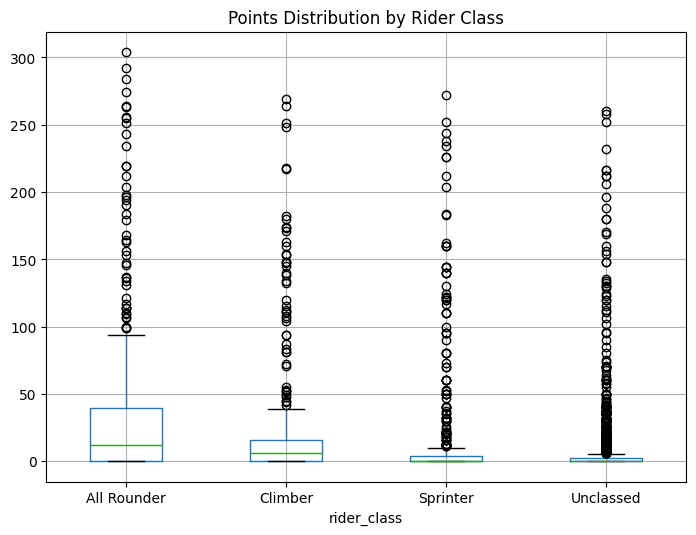

In [ ]:
df.boxplot(column='points', by='rider_class', figsize=(8,6))
plt.title("Points Distribution by Rider Class")
plt.suptitle("")
plt.show()

In [ ]:
# Prepare groups
groups = {name: g['points'].dropna().values for name, g in df.groupby('rider_class')}
group_names = list(groups.keys())

In [ ]:
# Kruskal-Wallis
kw_stat, kw_p = stats.kruskal(*groups.values())

kw_stat, kw_p

NameError: name 'stats' is not defined